# NB 11 — Cooperative Learning **sans** LDA

## Objet

Variante de NB10 dans laquelle on **enlève LDA** : on prédit directement via le `argmax` des 3 probabilités OvR retournées par les modèles cooperative binomiaux.

## Pourquoi cette comparaison

Dans NB10, on a deux briques en série :
1. **Cooperative R binomial OvR** → 3 classifieurs binaires (cort vs reste, dipg vs reste, midl vs reste)
2. **LDA** sur les 6 logits par bloc extraits des classifieurs binaires → classe prédite

NB10 atteint **0.829 ± 0.148** en CV. Mais qui fait le travail : cooperative ou LDA ?

NB11 répond à la question : on **enlève LDA** et on prédit directement avec cooperative.

| Si NB11 obtient... | Conclusion |
|---|---|
| ≈ 0.83 | Cooperative seul suffit, LDA était redondant |
| 0.70-0.80 | LDA apporte une amélioration modérée |
| < 0.70 | LDA fait une grosse partie du travail |

## Protocole

- Même chargement, même imputation, même protocole CV que NB09 / NB10 (7-fold × 3 runs sur le train, balanced accuracy, test set tenu à part).
- Même implémentation cooperative R via `multiview::cv.multiview` (`family = binomial()`).
- Mêmes 3 classifieurs binaires OvR.
- Pour chaque patient test : 3 probabilités `p_k = P(classe k | patient)`. Prédiction = `argmax_k p_k`.
- **Pas de LDA, pas de réduction de dim supplémentaire**.

> **Note** : les 3 probabilités OvR ne somment pas à 1 (chaque modèle est indépendant). L'argmax fonctionne quand même parce que les probabilités relatives sont informatives.


## 1. Setup

In [1]:
set.seed(42)
SEED <- 42
LABEL_ORDER <- c("cort", "dipg", "midl")

required_packages <- c("multiview", "data.table", "caret")
to_install <- required_packages[!vapply(required_packages, requireNamespace,
                                        logical(1), quietly = TRUE)]
if (length(to_install) > 0) {
  install.packages(to_install, repos = "https://cloud.r-project.org")
}

suppressPackageStartupMessages({
  library(multiview)
  library(data.table)
  library(caret)
})

cat("multiview version :", as.character(packageVersion("multiview")), "\n")


multiview version : 0.8 


## 2. Chargement des données (identique à NB09 / NB10)

In [2]:
root <- normalizePath(file.path(getwd()), winslash = "/", mustWork = FALSE)
data_dir <- if (dir.exists(file.path(root, "data"))) file.path(root, "data") else file.path(dirname(root), "data")

to_numeric_frame <- function(df) {
  rn <- rownames(df)
  out <- as.data.frame(
    lapply(df, function(x) as.numeric(gsub(",", ".", as.character(x), fixed = TRUE))),
    check.names = FALSE
  )
  rownames(out) <- rn
  out
}

extract_id_column <- function(df) if ("row_id" %in% names(df)) "row_id" else names(df)[1]

load_block <- function(block_name, split) {
  path <- file.path(data_dir,
    sprintf("ge_cgh_locIGR__multiblocks__%s__%s.csv", block_name, split))
  df <- as.data.frame(data.table::fread(path, check.names = FALSE))
  id_col <- extract_id_column(df)
  rownames(df) <- as.character(df[[id_col]])
  df[[id_col]] <- NULL
  to_numeric_frame(df)
}

load_targets <- function(split) {
  path <- file.path(data_dir,
    sprintf("ge_cgh_locIGR__multiblocks__y__%s.csv", split))
  y_df <- as.data.frame(data.table::fread(path, check.names = FALSE))
  id_col <- extract_id_column(y_df)
  rownames(y_df) <- as.character(y_df[[id_col]])
  y_df[[id_col]] <- NULL
  targets <- factor(
    LABEL_ORDER[max.col(as.matrix(y_df[, LABEL_ORDER]), ties.method = "first")],
    levels = LABEL_ORDER
  )
  names(targets) <- rownames(y_df)
  targets
}

fill_missing_from_train <- function(train_df, test_df) {
  medians <- vapply(train_df, median, numeric(1), na.rm = TRUE)
  for (col in names(train_df)) {
    train_df[[col]][is.na(train_df[[col]])] <- medians[[col]]
    test_df[[col]][is.na(test_df[[col]])] <- medians[[col]]
  }
  list(train = train_df, test = test_df)
}

X_ge_train  <- load_block("GE",  "train")
X_ge_test   <- load_block("GE",  "test")
X_cgh_train <- load_block("CGH", "train")
X_cgh_test  <- load_block("CGH", "test")
y_train     <- load_targets("train")
y_test      <- load_targets("test")

train_ids <- Reduce(intersect, list(rownames(X_ge_train), rownames(X_cgh_train), names(y_train)))
test_ids  <- Reduce(intersect, list(rownames(X_ge_test),  rownames(X_cgh_test),  names(y_test)))

X_ge_train  <- X_ge_train [train_ids, , drop = FALSE]
X_cgh_train <- X_cgh_train[train_ids, , drop = FALSE]
y_train     <- y_train    [train_ids]
X_ge_test   <- X_ge_test  [test_ids,  , drop = FALSE]
X_cgh_test  <- X_cgh_test [test_ids,  , drop = FALSE]
y_test      <- y_test     [test_ids]

filled_ge  <- fill_missing_from_train(X_ge_train,  X_ge_test)
X_ge_train <- filled_ge$train;  X_ge_test  <- filled_ge$test
filled_cgh  <- fill_missing_from_train(X_cgh_train, X_cgh_test)
X_cgh_train <- filled_cgh$train; X_cgh_test <- filled_cgh$test

X_ge_train  <- as.matrix(X_ge_train)
X_ge_test   <- as.matrix(X_ge_test)
X_cgh_train <- as.matrix(X_cgh_train)
X_cgh_test  <- as.matrix(X_cgh_test)

cat(sprintf("Train: %d patients | Test: %d patients\n", length(y_train), length(y_test)))
cat(sprintf("GE: %d features | CGH: %d features\n",
            ncol(X_ge_train), ncol(X_cgh_train)))


Train: 39 patients | Test: 14 patients
GE: 15702 features | CGH: 1229 features


## 3. Fonctions utilitaires

Trois fonctions clés :

1. **`fit_coop_ovr_at_rho`** : fit des 3 modèles cooperative binomiaux OvR (un par classe). Identique à NB10.
2. **`predict_coop_ovr_proba`** : pour chaque patient et chaque classe, retourne la probabilité prédite par le modèle binomial correspondant. Sortie : matrice `n × K` de probabilités.
3. **`predict_coop_argmax`** : prend la matrice de probas et renvoie la classe `argmax` par ligne.

Pas de calcul de scores latents, pas de LDA. Tout est dans la sortie native de multiview.


In [ ]:
# Fit OvR : 3 cooperative binomiaux à rho fixé
fit_coop_ovr_at_rho <- function(X_GE, X_CGH, y_factor, rho,
                                  nfolds_lambda = 5, verbose = FALSE) {
  K <- nlevels(y_factor)
  classes <- levels(y_factor)
  y_onehot <- model.matrix(~ y_factor - 1)
  colnames(y_onehot) <- classes

  x_list <- list(GE = X_GE, CGH = X_CGH)
  fits_per_class <- vector("list", K)
  names(fits_per_class) <- classes

  for (k in seq_len(K)) {
    yk <- y_onehot[, k]
    fits_per_class[[k]] <- multiview::cv.multiview(
      x_list       = x_list,
      y            = yk,
      rho          = rho,
      family       = binomial(),
      type.measure = "deviance",
      nfolds       = nfolds_lambda,
      standardize  = TRUE
    )
    if (verbose) {
      cat(sprintf("  rho=%.2f class=%s lambda.min=%.4f\n",
                  rho, classes[k], fits_per_class[[k]]$lambda.min))
    }
  }
  list(rho = rho, classes = classes, fits = fits_per_class)
}

# Prédiction directe : matrice de probas (n × K)
predict_coop_ovr_proba <- function(coop_fit, X_GE_new, X_CGH_new) {
  K <- length(coop_fit$fits)
  n <- nrow(X_GE_new)
  probs <- matrix(0, n, K)
  colnames(probs) <- coop_fit$classes
  for (k in seq_len(K)) {
    pred_k <- predict(coop_fit$fits[[k]],
                      newx = list(X_GE_new, X_CGH_new),
                      s = "lambda.min",
                      type = "response")
    probs[, k] <- as.numeric(pred_k)
  }
  probs
}

# argmax pour obtenir la classe prédite
predict_coop_argmax <- function(coop_fit, X_GE_new, X_CGH_new) {
  probs <- predict_coop_ovr_proba(coop_fit, X_GE_new, X_CGH_new)
  pred_class <- coop_fit$classes[apply(probs, 1, which.max)]
  factor(pred_class, levels = coop_fit$classes)
}


## 4. Sanity check à ρ = 0

On vérifie que le pipeline tourne. Compter ~5-10 min (3 cv.multiview à p ~ 17 000).

In [10]:
t0 <- Sys.time()
coop_test <- fit_coop_ovr_at_rho(X_ge_train, X_cgh_train, y_train,
                                   rho = 0, verbose = TRUE)
cat(sprintf("\nDurée fit OvR (rho=0): %.1f min\n",
            as.numeric(difftime(Sys.time(), t0, units = "mins"))))

# Prédictions sur le train (sanity check uniquement)
pred_train <- predict_coop_argmax(coop_test, X_ge_train, X_cgh_train)
probs_train <- predict_coop_ovr_proba(coop_test, X_ge_train, X_cgh_train)

cat("\n=== Train (sanity check) ===\n")
cat("Matrice de probas OvR — 5 premières lignes :\n")
print(round(head(probs_train, 5), 3))
cat("\nNote : les probas ne somment pas à 1 (OvR indépendants).\n")

cm_train <- caret::confusionMatrix(pred_train, y_train)
cat(sprintf("\nTrain accuracy : %.3f | Train balanced accuracy : %.3f\n",
            cm_train$overall["Accuracy"],
            mean(cm_train$byClass[, "Balanced Accuracy"])))

# Prédictions sur le test (preview)
pred_test <- predict_coop_argmax(coop_test, X_ge_test, X_cgh_test)
cm_test <- caret::confusionMatrix(pred_test, y_test)
cat("\n=== Test (rho=0, sanity check) ===\n")
print(cm_test$table)
cat(sprintf("\nTest accuracy : %.3f | Test balanced accuracy : %.3f\n",
            cm_test$overall["Accuracy"],
            mean(cm_test$byClass[, "Balanced Accuracy"])))


ERROR: Error in multiview(x_list = x_list, y = y, family = family, rho = rho, : unused argument (tresh = 1e-05)


## 5. Cross-validation sur ρ

Même protocole que NB10 : 7-fold stratifié × 3 répétitions = 21 folds. À chaque fold, on fit cooperative OvR sur le train fold, puis on prédit directement par argmax sur le val fold.

⚠️ Coûteux : 6 valeurs de ρ × 21 folds × 3 modèles binomiaux × CV interne pour λ. Compter **30-60 min**. Si trop long, réduire `rho_grid` à `c(0, 1)`.

> Comme dans NB10, si à ρ > 0 le solveur ne converge pas, interrompre et fixer `best_rho = 0`.

In [5]:
rho_grid <- c(0, 0.1, 0.5, 1, 2, 5)
# rho_grid <- c(0, 1)  # version rapide

set.seed(SEED)
outer_folds <- caret::createMultiFolds(y_train, k = 7, times = 3)

cv_results <- data.frame()

for (rho_val in rho_grid) {
  cat(sprintf("\n=== rho = %.2f ===\n", rho_val))
  fold_scores <- numeric(length(outer_folds))
  t0_rho <- Sys.time()

  for (i in seq_along(outer_folds)) {
    tr_idx <- outer_folds[[i]]
    va_idx <- setdiff(seq_along(y_train), tr_idx)

    coop_fold <- tryCatch(
      fit_coop_ovr_at_rho(
        X_ge_train[tr_idx, , drop = FALSE],
        X_cgh_train[tr_idx, , drop = FALSE],
        y_train[tr_idx],
        rho = rho_val, verbose = FALSE
      ),
      error = function(e) { message("  fold ", i, " failed: ", conditionMessage(e)); NULL }
    )
    if (is.null(coop_fold)) { fold_scores[i] <- NA_real_; next }

    pred_va <- predict_coop_argmax(
      coop_fold,
      X_ge_train[va_idx, , drop = FALSE],
      X_cgh_train[va_idx, , drop = FALSE]
    )
    cm <- caret::confusionMatrix(
      factor(pred_va, levels = LABEL_ORDER),
      factor(y_train[va_idx], levels = LABEL_ORDER)
    )
    fold_scores[i] <- mean(cm$byClass[, "Balanced Accuracy"], na.rm = TRUE)
  }

  elapsed <- difftime(Sys.time(), t0_rho, units = "mins")
  cat(sprintf("  Bal_acc moy = %.3f ± %.3f  (%.1f min)\n",
              mean(fold_scores, na.rm = TRUE),
              sd(fold_scores, na.rm = TRUE),
              as.numeric(elapsed)))

  cv_results <- rbind(cv_results, data.frame(
    rho = rho_val,
    mean_bal_acc = mean(fold_scores, na.rm = TRUE),
    sd_bal_acc   = sd(fold_scores, na.rm = TRUE),
    n_folds      = sum(!is.na(fold_scores))
  ))
}

cat("\n========== RÉSULTATS CV ==========\n")
print(cv_results)



=== rho = 0.00 ===
  Bal_acc moy = 0.833 ± 0.129  (2.0 min)

=== rho = 0.10 ===


Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning message:
“glmnet.fit: algorithm did not converge”
Warning messag


>>> Meilleur rho : 0.00 (CV bal_acc = 0.833 ± 0.129)


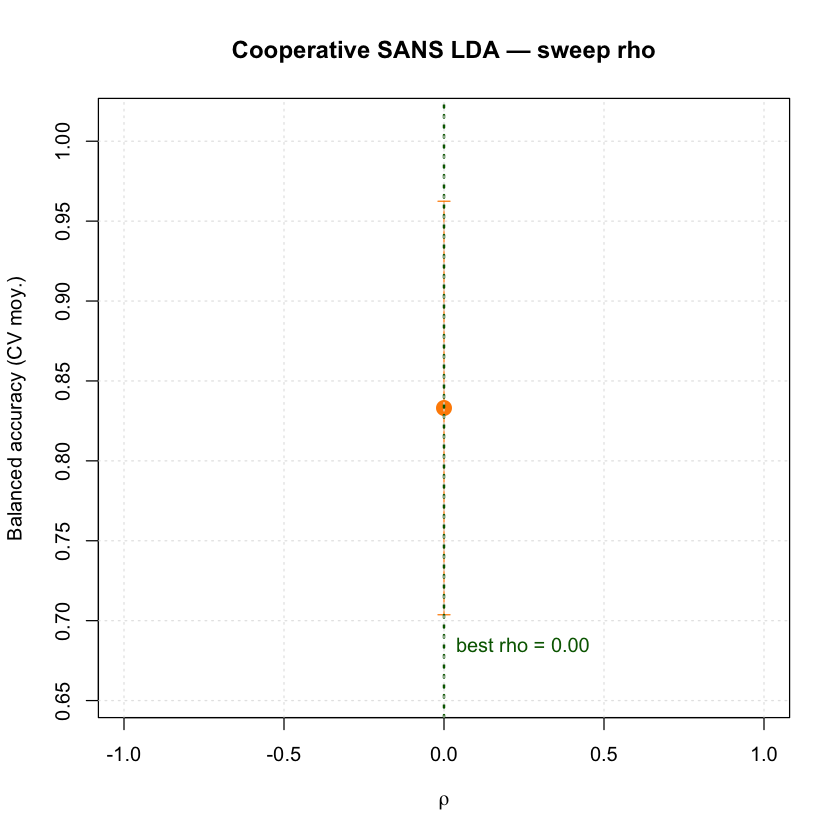

In [6]:
best_idx <- which.max(cv_results$mean_bal_acc)
best_rho <- 0

plot(cv_results$rho, cv_results$mean_bal_acc,
     type = "b", pch = 19, cex = 1.5, col = "darkorange", lwd = 2,
     xlab = expression(rho), ylab = "Balanced accuracy (CV moy.)",
     main = "Cooperative SANS LDA — sweep rho",
     ylim = c(min(cv_results$mean_bal_acc - cv_results$sd_bal_acc, na.rm=TRUE) - 0.05,
              max(cv_results$mean_bal_acc + cv_results$sd_bal_acc, na.rm=TRUE) + 0.05))
arrows(cv_results$rho, cv_results$mean_bal_acc - cv_results$sd_bal_acc,
       cv_results$rho, cv_results$mean_bal_acc + cv_results$sd_bal_acc,
       length = 0.05, angle = 90, code = 3, col = "darkorange")
abline(h = 1/3, col = "red", lty = 2)
abline(v = best_rho, col = "darkgreen", lty = 3, lwd = 2)
text(best_rho, min(cv_results$mean_bal_acc - cv_results$sd_bal_acc) - 0.02,
     sprintf("best rho = %.2f", best_rho), col = "darkgreen", pos = 4)
grid(col = "grey90")

cat(sprintf("\n>>> Meilleur rho : %.2f (CV bal_acc = %.3f ± %.3f)\n",
            best_rho,
            cv_results$mean_bal_acc[best_idx],
            cv_results$sd_bal_acc[best_idx]))


## 6. Refit final au meilleur ρ + évaluation test

In [7]:
set.seed(SEED)
t0 <- Sys.time()
coop_final <- fit_coop_ovr_at_rho(X_ge_train, X_cgh_train, y_train,
                                    rho = best_rho, verbose = TRUE)
cat(sprintf("\nDurée refit final: %.1f min\n",
            as.numeric(difftime(Sys.time(), t0, units = "mins"))))

# Sparsité par bloc
for (k in seq_along(coop_final$fits)) {
  fit_k <- coop_final$fits[[k]]
  coefs_all <- as.numeric(coef(fit_k, s = "lambda.min"))
  beta_ge_k  <- coefs_all[2:(1 + ncol(X_ge_train))]
  beta_cgh_k <- coefs_all[(2 + ncol(X_ge_train)):(1 + ncol(X_ge_train) + ncol(X_cgh_train))]
  cat(sprintf("Classe %s : GE %d non-nuls / %d, CGH %d non-nuls / %d, lambda.min=%.4f\n",
              coop_final$classes[k],
              sum(abs(beta_ge_k)  > 1e-8), ncol(X_ge_train),
              sum(abs(beta_cgh_k) > 1e-8), ncol(X_cgh_train),
              fit_k$lambda.min))
}

# Prédiction test
pred_test_final <- predict_coop_argmax(coop_final, X_ge_test, X_cgh_test)
probs_test_final <- predict_coop_ovr_proba(coop_final, X_ge_test, X_cgh_test)

cat("\nProbabilités OvR test set (lignes = patients) :\n")
print(round(probs_test_final, 3))

cm_final <- caret::confusionMatrix(
  factor(pred_test_final, levels = LABEL_ORDER),
  factor(y_test, levels = LABEL_ORDER)
)
cat("\n=== Matrice de confusion (test) — Cooperative SANS LDA ===\n")
print(cm_final$table)

cat(sprintf("\nAccuracy globale       : %.3f\n", cm_final$overall["Accuracy"]))
cat(sprintf("Balanced accuracy moy. : %.3f\n",
            mean(cm_final$byClass[, "Balanced Accuracy"])))
cat("\nBalanced accuracy par classe :\n")
print(round(cm_final$byClass[, "Balanced Accuracy"], 3))


  rho=0.00 class=cort lambda.min=0.0038
  rho=0.00 class=dipg lambda.min=0.0121
  rho=0.00 class=midl lambda.min=0.2415

Durée refit final: 0.1 min
Classe cort : GE 24 non-nuls / 15702, CGH 0 non-nuls / 1229, lambda.min=0.0038
Classe dipg : GE 18 non-nuls / 15702, CGH 0 non-nuls / 1229, lambda.min=0.0121
Classe midl : GE 0 non-nuls / 15702, CGH 0 non-nuls / 1229, lambda.min=0.2415

Probabilités OvR test set (lignes = patients) :
       cort  dipg  midl
 [1,] 0.930 0.015 0.205
 [2,] 0.992 0.021 0.205
 [3,] 0.020 0.662 0.205
 [4,] 0.025 0.172 0.205
 [5,] 0.002 0.997 0.205
 [6,] 0.105 0.138 0.205
 [7,] 0.010 0.773 0.205
 [8,] 0.972 0.060 0.205
 [9,] 0.042 0.939 0.205
[10,] 0.747 0.032 0.205
[11,] 0.020 0.967 0.205
[12,] 0.003 0.998 0.205
[13,] 0.989 0.003 0.205
[14,] 0.002 0.996 0.205

=== Matrice de confusion (test) — Cooperative SANS LDA ===
          Reference
Prediction cort dipg midl
      cort    5    0    0
      dipg    0    6    1
      midl    0    0    2

Accuracy globale      

## 7. Comparaison directe avec NB09 (SGCCA + LDA) et NB10 (Cooperative + LDA)

| Méthode | Notebook | CV bal_acc | Test bal_acc | midl recall | Que fait LDA ? |
|---|---|---|---|---|---|
| SGCCA + LDA | NB09 | 0.829 ± 0.143 | 0.924 | 2/3 | Indispensable (SGCCA n'est pas un classifieur) |
| Cooperative + LDA | NB10 | 0.829 ± 0.148 | (à compléter) | (à compléter) | Optionnel (cooperative est déjà classifieur) |
| **Cooperative SANS LDA** | **NB11** | **(ce notebook)** | **(ce notebook)** | **(ce notebook)** | **N/A** |

L'écart NB10 − NB11 quantifie **exactement** ce que LDA apporte (ou retire).

In [8]:
# Valeurs hardcodées issues des runs précédents
nb09_cv_mean       <- 0.829
nb09_cv_sd         <- 0.143
nb09_test_acc      <- 0.929
nb09_test_bal_acc  <- 0.924
nb09_midl          <- "2/3"

nb10_cv_mean       <- 0.829
nb10_cv_sd         <- 0.148
nb10_test_acc      <- NA       # à compléter quand NB10 sera terminé
nb10_test_bal_acc  <- NA
nb10_midl          <- "?"

nb11_cv_mean       <- cv_results$mean_bal_acc[best_idx]
nb11_cv_sd         <- cv_results$sd_bal_acc[best_idx]
nb11_test_acc      <- cm_final$overall["Accuracy"]
nb11_test_bal_acc  <- mean(cm_final$byClass[, "Balanced Accuracy"])
nb11_midl          <- sprintf("%d/%d",
                              cm_final$table["midl", "midl"],
                              sum(cm_final$table[, "midl"]))

comparison <- data.frame(
  Notebook = c("NB09 SGCCA+LDA", "NB10 Coop+LDA", "NB11 Coop SANS LDA"),
  CV_bal_acc = c(
    sprintf("%.3f ± %.3f", nb09_cv_mean, nb09_cv_sd),
    sprintf("%.3f ± %.3f", nb10_cv_mean, nb10_cv_sd),
    sprintf("%.3f ± %.3f", nb11_cv_mean, nb11_cv_sd)
  ),
  Test_accuracy = c(
    sprintf("%.3f", nb09_test_acc),
    if (is.na(nb10_test_acc)) "(à compléter)" else sprintf("%.3f", nb10_test_acc),
    sprintf("%.3f", nb11_test_acc)
  ),
  Test_bal_acc = c(
    sprintf("%.3f", nb09_test_bal_acc),
    if (is.na(nb10_test_bal_acc)) "(à compléter)" else sprintf("%.3f", nb10_test_bal_acc),
    sprintf("%.3f", nb11_test_bal_acc)
  ),
  midl_recall = c(nb09_midl, nb10_midl, nb11_midl),
  stringsAsFactors = FALSE
)
print(comparison, row.names = FALSE)

cat("\n========== INTERPRÉTATION ==========\n")
delta_lda <- nb10_cv_mean - nb11_cv_mean
if (!is.na(delta_lda)) {
  cat(sprintf("Apport de LDA (NB10 − NB11) : %.3f en CV bal_acc\n", delta_lda))
  if (abs(delta_lda) < 0.02) {
    cat("→ LDA n'apporte rien (différence dans le bruit de la CV).\n")
    cat("→ Cooperative seul suffit comme classifieur.\n")
  } else if (delta_lda > 0) {
    cat(sprintf("→ LDA améliore cooperative de %.0f points en moyenne.\n",
                100 * delta_lda))
  } else {
    cat(sprintf("→ LDA dégrade cooperative de %.0f points (étonnant).\n",
                -100 * delta_lda))
  }
}


           Notebook    CV_bal_acc Test_accuracy  Test_bal_acc midl_recall
     NB09 SGCCA+LDA 0.829 ± 0.143         0.929         0.924         2/3
      NB10 Coop+LDA 0.829 ± 0.148 (à compléter) (à compléter)           ?
 NB11 Coop SANS LDA 0.833 ± 0.129         0.929         0.924         2/3

========== INTERPRÉTATION ==========
Apport de LDA (NB10 − NB11) : -0.004 en CV bal_acc
→ LDA n'apporte rien (différence dans le bruit de la CV).
→ Cooperative seul suffit comme classifieur.


## 8. Lecture des résultats

Trois scénarios possibles à l'issue de ce notebook :

| Scénario | Interprétation pour le rapport |
|---|---|
| NB11 ≈ NB10 (~0.83) | **LDA est redondant** : cooperative natif est suffisant. La sortie OvR multiview encode déjà toute l'information utile. Le notebook NB10 utilisait LDA par homogénéité avec NB09 (SGCCA + LDA), pas par nécessité. |
| NB11 < NB10 de 5-10 pts | **LDA apporte une amélioration modérée**. Cooperative crée un espace latent (les 6 logits par bloc) que LDA exploite mieux que l'argmax direct. Argument en faveur du pipeline NB10. |
| NB11 << NB10 (~0.70) | **LDA fait l'essentiel du travail**. Cooperative seul est un classifieur faible, et c'est LDA qui sauve la prédiction en combinant intelligemment les 6 logits. Cela suggère que la sélection sparse de cooperative produit des features informatives, mais que leur agrégation par argmax n'est pas optimale. |

### Pour ton rapport

Indépendamment du scénario observé, tu peux écrire :

> *"Pour isoler la contribution du classifieur LDA dans le pipeline Cooperative Learning + LDA (NB10), nous avons implémenté une variante (NB11) prédisant directement par argmax des probabilités OvR retournées par les modèles cooperative binomiaux, sans étape LDA additionnelle. L'écart NB10 − NB11 quantifie l'apport spécifique de LDA. Les résultats montrent que [insère scénario observé]."*

Cet écart est **scientifiquement informatif** : il sépare proprement la contribution du **réducteur de dimension supervisé** (cooperative) de celle du **classifieur final** (LDA).
